# Multimodel Probe Validation Analysis

This notebook compares all trained temporal probes across the full 12-case grid:

- Probe methods: `lr`, `dmm`, `attn`
- Models: `gpt2`, `Qwen3-4B`, `Phi-3-mini-4k-instruct`, `Llama-3.2-3B`

The intended scientific direction is: train on the implicit AB-randomized dataset, then validate on the explicit AB-randomized dataset. High explicit cross-dataset accuracy suggests the probe is capturing a temporal feature that transfers beyond the implicit training distribution.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
VALIDATION_DIR = ROOT / 'results' / 'probe_validation'
FIGURE_DIR = ROOT / 'results' / 'figures' / 'probe_validation_multimethod'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ['lr', 'dmm', 'attn']
METHOD_LABELS = {
    'lr': 'LR',
    'dmm': 'DMM',
    'attn': 'AttnProbe',
}
MODEL_ORDER = ['gpt2', 'Qwen3-4B', 'Phi-3-mini-4k-instruct', 'Llama-3.2-3B']
MODEL_LABELS = {
    'gpt2': 'GPT-2',
    'Qwen3-4B': 'Qwen3-4B',
    'Phi-3-mini-4k-instruct': 'Phi-3-mini',
    'Llama-3.2-3B': 'Llama-3.2-3B',
}
METHOD_COLORS = {
    'lr': '#2764a5',
    'dmm': '#2d8f6f',
    'attn': '#c04f33',
}

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.titleweight': 'bold',
    'font.size': 10,
})

print(f'Loading validation files from: {VALIDATION_DIR.relative_to(ROOT)}')

Loading validation files from: results/probe_validation


## Load Results

Only method-scoped validation folders are loaded here. Legacy root-level validation JSONs are intentionally ignored so old LR-only outputs cannot mix with the new 12-case pipeline.


In [2]:
def model_short_name(model_name: str) -> str:
    return model_name.split('/')[-1]


def load_validation_results(validation_dir: Path):
    rows = []
    layer_rows = []
    loaded = {}

    for method in METHOD_ORDER:
        method_dir = validation_dir / method
        for path in sorted(method_dir.glob(f'*_probe_validation_{method}.json')):
            data = json.loads(path.read_text())
            model_name = data['metadata']['model']['name']
            model_tag = data['metadata']['model']['tag']
            model_short = model_short_name(model_name)
            summary = data['summary']
            config = data['config']

            key = (method, model_short)
            loaded[key] = data

            rows.append({
                'method': method,
                'method_label': METHOD_LABELS[method],
                'model': model_short,
                'model_label': MODEL_LABELS.get(model_short, model_short),
                'model_name': model_name,
                'model_tag': model_tag,
                'best_layer': summary['best_semantic_layer'],
                'best_explicit_acc': summary['best_explicit_accuracy'],
                'best_implicit_acc_at_best_explicit': summary['best_implicit_accuracy'],
                'validation_passed': summary['validation_passed'],
                'mean_explicit_acc': summary['mean_explicit_accuracy'],
                'mean_implicit_acc': summary['mean_implicit_accuracy'],
                'mean_gap_explicit_minus_implicit': summary['mean_generalization_gap'],
                'n_semantic_layers': len(summary['semantic_layers']),
                'n_weak_layers': len(summary['weak_layers']),
                'n_lexical_layers': len(summary['lexical_layers']),
                'probe_type': config['probe_type'],
                'n_explicit_pairs': config['n_explicit_pairs'],
                'n_implicit_pairs': config['n_implicit_pairs'],
                'source_json': str(path.relative_to(ROOT)),
            })

            explicit_df = pd.DataFrame(data['explicit_results'])
            implicit_df = pd.DataFrame(data['implicit_results'])
            merged = explicit_df.merge(implicit_df, on=['layer', 'probe_method'], how='inner')
            if merged.empty:
                raise ValueError(f'No merged layer rows for {path}')
            max_layer = merged['layer'].max()
            denom = max(max_layer, 1)
            merged['layer_frac'] = merged['layer'] / denom
            merged['gap_explicit_minus_implicit'] = merged['explicit_acc'] - merged['implicit_acc']
            merged['method'] = method
            merged['method_label'] = METHOD_LABELS[method]
            merged['model'] = model_short
            merged['model_label'] = MODEL_LABELS.get(model_short, model_short)
            merged['model_name'] = model_name
            merged['model_tag'] = model_tag
            layer_rows.append(merged)

    summary_df = pd.DataFrame(rows)
    layer_df = pd.concat(layer_rows, ignore_index=True)

    summary_df['method'] = pd.Categorical(summary_df['method'], METHOD_ORDER, ordered=True)
    summary_df['model'] = pd.Categorical(summary_df['model'], MODEL_ORDER, ordered=True)
    summary_df = summary_df.sort_values(['method', 'model']).reset_index(drop=True)

    layer_df['method'] = pd.Categorical(layer_df['method'], METHOD_ORDER, ordered=True)
    layer_df['model'] = pd.Categorical(layer_df['model'], MODEL_ORDER, ordered=True)
    layer_df = layer_df.sort_values(['method', 'model', 'layer']).reset_index(drop=True)

    return loaded, summary_df, layer_df


loaded, summary_df, layer_df = load_validation_results(VALIDATION_DIR)
print(f'Loaded {len(summary_df)} model/probe validation files')
print(f'Loaded {len(layer_df)} layer-level rows')

missing = [
    (method, model)
    for method in METHOD_ORDER
    for model in MODEL_ORDER
    if (method, model) not in loaded
]
if missing:
    display(Markdown('**Missing cases:** ' + ', '.join(f'{m}/{mod}' for m, mod in missing)))
else:
    display(Markdown('**All 12 expected probe/model cases are present.**'))

Loaded 12 model/probe validation files
Loaded 324 layer-level rows


**All 12 expected probe/model cases are present.**

## Summary Table

`best_explicit_acc` is the main cross-dataset validation metric. `mean_gap_explicit_minus_implicit` is positive when explicit validation is easier than the implicit held-out split and negative when implicit test accuracy is higher than explicit validation.


In [3]:
summary_display = summary_df[[
    'method_label', 'model_label', 'best_layer', 'best_explicit_acc',
    'best_implicit_acc_at_best_explicit', 'mean_explicit_acc', 'mean_implicit_acc',
    'mean_gap_explicit_minus_implicit', 'n_semantic_layers', 'validation_passed'
]].rename(columns={
    'method_label': 'Probe',
    'model_label': 'Model',
    'best_layer': 'Best layer',
    'best_explicit_acc': 'Best explicit acc',
    'best_implicit_acc_at_best_explicit': 'Implicit acc at best explicit layer',
    'mean_explicit_acc': 'Mean explicit acc',
    'mean_implicit_acc': 'Mean implicit acc',
    'mean_gap_explicit_minus_implicit': 'Mean gap',
    'n_semantic_layers': '# explicit >= 70%',
    'validation_passed': 'Passed',
})

styled = summary_display.style.format({
    'Best explicit acc': '{:.1%}',
    'Implicit acc at best explicit layer': '{:.1%}',
    'Mean explicit acc': '{:.1%}',
    'Mean implicit acc': '{:.1%}',
    'Mean gap': '{:+.1%}',
})
styled

,Probe,Model,Best layer,Best explicit acc,Implicit acc at best explicit layer,Mean explicit acc,Mean implicit acc,Mean gap,# explicit >= 70%,Passed
0,LR,GPT-2,4,79.0%,60.0%,73.8%,70.8%,+2.9%,9,True
1,LR,Qwen3-4B,18,93.0%,100.0%,84.8%,92.6%,-7.9%,34,True
2,LR,Phi-3-mini,17,94.0%,90.0%,85.8%,89.4%,-3.6%,28,True
3,LR,Llama-3.2-3B,9,92.0%,95.0%,83.5%,87.5%,-4.0%,27,True
4,DMM,GPT-2,8,74.0%,85.0%,70.3%,74.2%,-3.8%,7,True
5,DMM,Qwen3-4B,16,93.0%,100.0%,84.2%,90.8%,-6.6%,33,True
6,DMM,Phi-3-mini,14,92.0%,95.0%,84.1%,88.1%,-4.0%,30,True
7,DMM,Llama-3.2-3B,9,91.0%,95.0%,82.3%,84.1%,-1.8%,27,True
8,AttnProbe,GPT-2,0,60.0%,45.0%,51.2%,55.4%,-4.2%,0,False
9,AttnProbe,Qwen3-4B,31,72.0%,65.0%,58.3%,58.1%,+0.2%,2,True


## Automatic Takeaways

These are generated from the current result files, so they update if probes are rerun.


In [4]:
best_overall = summary_df.loc[summary_df['best_explicit_acc'].idxmax()]
mean_by_method = summary_df.groupby('method', observed=True)['mean_explicit_acc'].mean().sort_values(ascending=False)
best_by_model = summary_df.loc[summary_df.groupby('model', observed=True)['best_explicit_acc'].idxmax()]
failed = summary_df[~summary_df['validation_passed']]

lines = [
    f"- Best single case: **{METHOD_LABELS[best_overall['method']]} / {MODEL_LABELS.get(best_overall['model'], best_overall['model'])}** at layer **{int(best_overall['best_layer'])}** with explicit accuracy **{best_overall['best_explicit_acc']:.1%}**.",
    f"- Highest average explicit accuracy by method: **{METHOD_LABELS[mean_by_method.index[0]]}** with mean explicit accuracy **{mean_by_method.iloc[0]:.1%}** across models.",
]

for row in best_by_model.sort_values('model').itertuples(index=False):
    lines.append(
        f"- Best probe for **{MODEL_LABELS.get(row.model, row.model)}**: "
        f"**{METHOD_LABELS[row.method]}** at layer **{int(row.best_layer)}** "
        f"with explicit accuracy **{row.best_explicit_acc:.1%}**."
    )

if failed.empty:
    lines.append('- All 12 cases pass the 70% explicit-accuracy criterion.')
else:
    failed_cases = ', '.join(
        f"{METHOD_LABELS[row.method]}/{MODEL_LABELS.get(row.model, row.model)} ({row.best_explicit_acc:.1%})"
        for row in failed.itertuples(index=False)
    )
    lines.append(f"- Cases below the 70% explicit validation threshold: {failed_cases}.")

display(Markdown('\n'.join(lines)))

- Best single case: **LR / Phi-3-mini** at layer **17** with explicit accuracy **94.0%**.
- Highest average explicit accuracy by method: **LR** with mean explicit accuracy **81.9%** across models.
- Best probe for **GPT-2**: **LR** at layer **4** with explicit accuracy **79.0%**.
- Best probe for **Qwen3-4B**: **LR** at layer **18** with explicit accuracy **93.0%**.
- Best probe for **Phi-3-mini**: **LR** at layer **17** with explicit accuracy **94.0%**.
- Best probe for **Llama-3.2-3B**: **LR** at layer **9** with explicit accuracy **92.0%**.
- Cases below the 70% explicit validation threshold: AttnProbe/GPT-2 (60.0%), AttnProbe/Llama-3.2-3B (67.0%).

## Best Explicit Accuracy Across All 12 Cases

This is the quickest dashboard for which probe/model combinations cross-validate best.


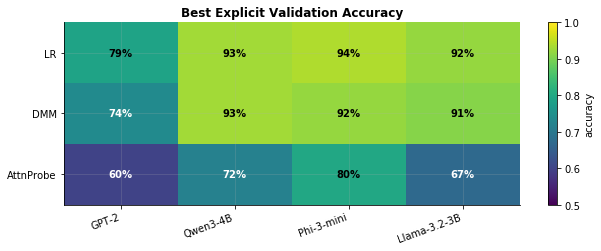

In [5]:
def heatmap_from_pivot(pivot, title, cbar_label, filename, vmin=0.5, vmax=1.0, fmt='{:.0%}', cmap='viridis'):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    im = ax.imshow(pivot.values, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            text_color = 'white' if val < (vmin + vmax) / 2 else 'black'
            ax.text(j, i, fmt.format(val), ha='center', va='center', color=text_color, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches='tight')
    return fig, ax

acc_pivot = summary_df.pivot(index='method_label', columns='model_label', values='best_explicit_acc')
acc_pivot = acc_pivot.loc[[METHOD_LABELS[m] for m in METHOD_ORDER], [MODEL_LABELS[m] for m in MODEL_ORDER]]
heatmap_from_pivot(
    acc_pivot,
    'Best Explicit Validation Accuracy',
    'accuracy',
    'best_explicit_accuracy_heatmap.png',
    vmin=0.5,
    vmax=1.0,
    cmap='viridis',
);

## Mean Explicit Accuracy Across Layers

The previous heatmap can reward a single lucky layer. This one asks whether the probe has a broad layer range with transferable signal.


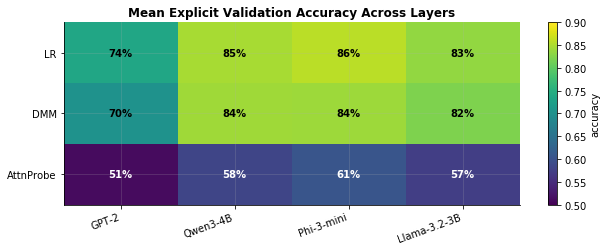

In [6]:
mean_pivot = summary_df.pivot(index='method_label', columns='model_label', values='mean_explicit_acc')
mean_pivot = mean_pivot.loc[[METHOD_LABELS[m] for m in METHOD_ORDER], [MODEL_LABELS[m] for m in MODEL_ORDER]]
heatmap_from_pivot(
    mean_pivot,
    'Mean Explicit Validation Accuracy Across Layers',
    'accuracy',
    'mean_explicit_accuracy_heatmap.png',
    vmin=0.5,
    vmax=0.9,
    cmap='viridis',
);

## Layer Curves: Explicit vs Implicit

Each subplot compares held-out implicit accuracy from training with explicit cross-dataset validation accuracy. The dashed line marks 70%, and the vertical dotted line marks the best explicit layer.


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


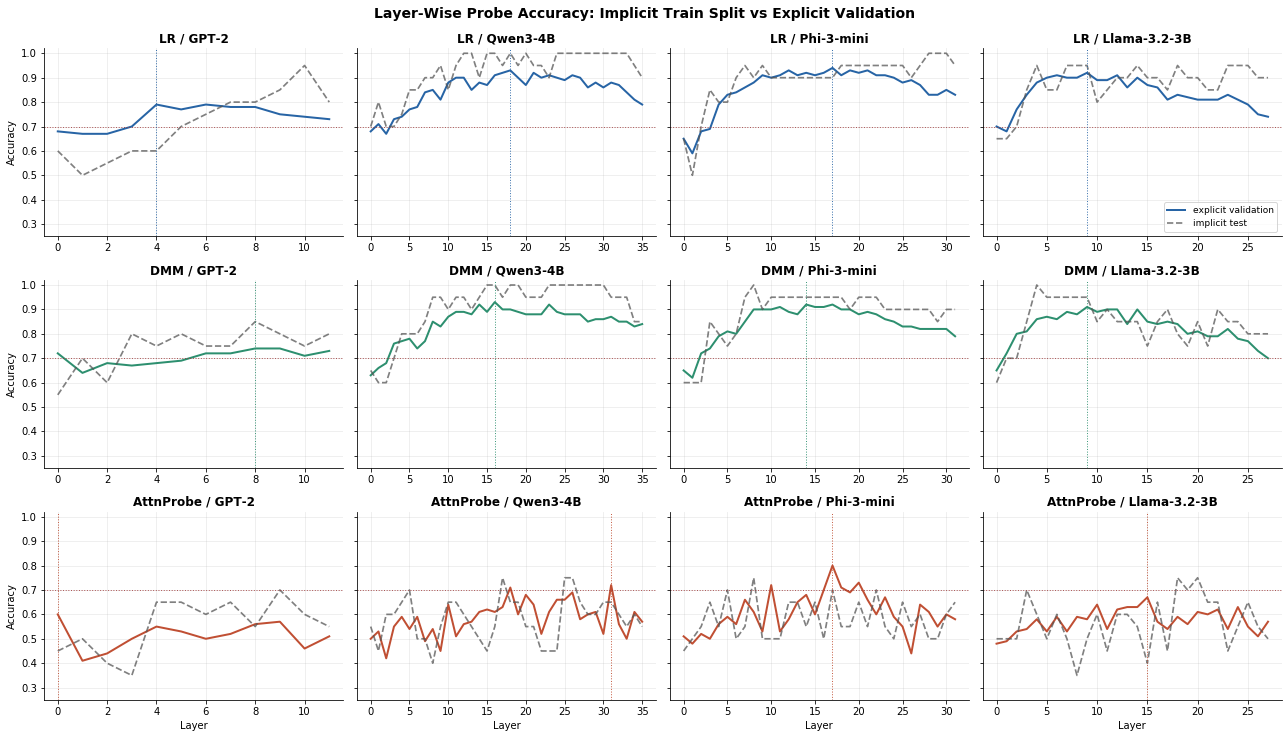

In [7]:
def plot_layer_grid(metric_explicit='explicit_acc', metric_implicit='implicit_acc'):
    fig, axes = plt.subplots(len(METHOD_ORDER), len(MODEL_ORDER), figsize=(18, 10), sharey=True)
    for i, method in enumerate(METHOD_ORDER):
        for j, model in enumerate(MODEL_ORDER):
            ax = axes[i, j]
            sub = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)]
            if sub.empty:
                ax.set_visible(False)
                continue
            ax.plot(sub['layer'], sub[metric_explicit], label='explicit validation', color=METHOD_COLORS[method], lw=2)
            ax.plot(sub['layer'], sub[metric_implicit], label='implicit test', color='#555555', lw=1.7, alpha=0.75, linestyle='--')
            best = summary_df[(summary_df['method'] == method) & (summary_df['model'] == model)].iloc[0]
            ax.axhline(0.70, color='#9c2f2f', lw=1, ls=':', alpha=0.8)
            ax.axvline(best['best_layer'], color=METHOD_COLORS[method], lw=1, ls=':', alpha=0.9)
            ax.set_ylim(0.25, 1.02)
            ax.set_title(f"{METHOD_LABELS[method]} / {MODEL_LABELS.get(model, model)}")
            if i == len(METHOD_ORDER) - 1:
                ax.set_xlabel('Layer')
            if j == 0:
                ax.set_ylabel('Accuracy')
            if i == 0 and j == len(MODEL_ORDER) - 1:
                ax.legend(loc='lower right', fontsize=9)
    fig.suptitle('Layer-Wise Probe Accuracy: Implicit Train Split vs Explicit Validation', y=1.02, fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'layer_accuracy_grid_all_cases.png', dpi=180, bbox_inches='tight')
    return fig, axes

plot_layer_grid();

## Normalized Depth View

Models have different numbers of layers, so raw layer indices are not directly comparable. This plot maps each model to fractional depth from input-side layers to output-side layers.


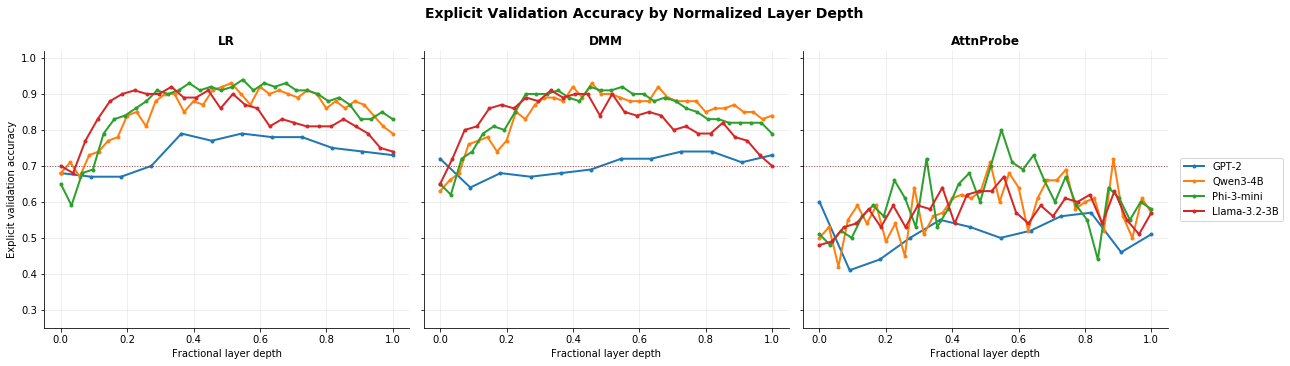

In [8]:
fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(18, 4.8), sharey=True)
for ax, method in zip(axes, METHOD_ORDER):
    for model in MODEL_ORDER:
        sub = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)]
        if sub.empty:
            continue
        ax.plot(
            sub['layer_frac'],
            sub['explicit_acc'],
            lw=2,
            marker='o',
            ms=3,
            label=MODEL_LABELS.get(model, model),
        )
    ax.axhline(0.70, color='#9c2f2f', lw=1, ls=':', alpha=0.8)
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Fractional layer depth')
    ax.set_ylim(0.25, 1.02)
axes[0].set_ylabel('Explicit validation accuracy')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.suptitle('Explicit Validation Accuracy by Normalized Layer Depth', y=1.05, fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'normalized_depth_explicit_accuracy.png', dpi=180, bbox_inches='tight')
plt.show()

## Generalization Gap Diagnostics

`explicit - implicit` helps reveal whether cross-dataset validation is harder or easier than the implicit held-out split. Large negative values mean the probe looks stronger on the implicit split than on explicit transfer.


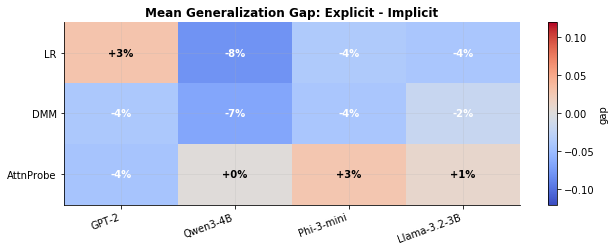

In [9]:
gap_pivot = summary_df.pivot(index='method_label', columns='model_label', values='mean_gap_explicit_minus_implicit')
gap_pivot = gap_pivot.loc[[METHOD_LABELS[m] for m in METHOD_ORDER], [MODEL_LABELS[m] for m in MODEL_ORDER]]
heatmap_from_pivot(
    gap_pivot,
    'Mean Generalization Gap: Explicit - Implicit',
    'gap',
    'mean_generalization_gap_heatmap.png',
    vmin=-0.12,
    vmax=0.12,
    fmt='{:+.0%}',
    cmap='coolwarm',
);

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


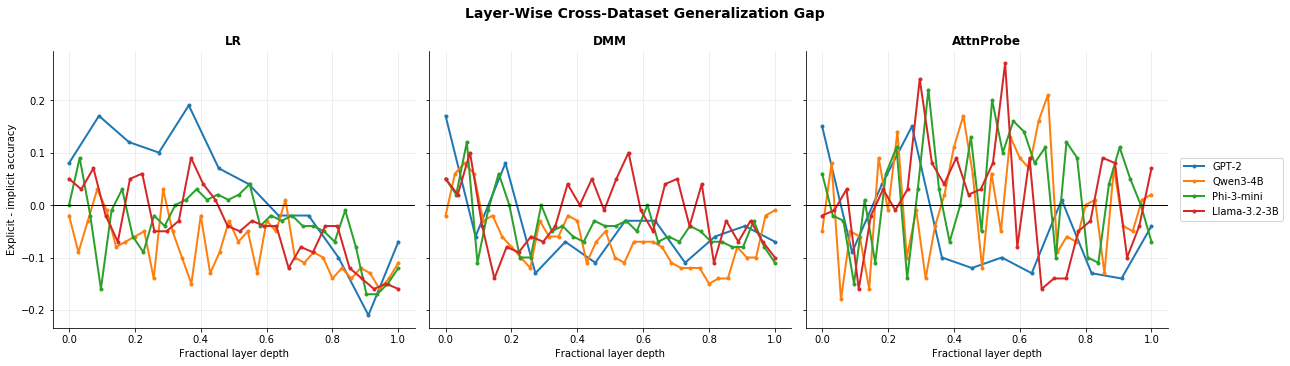

In [10]:
fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(18, 4.8), sharey=True)
for ax, method in zip(axes, METHOD_ORDER):
    for model in MODEL_ORDER:
        sub = layer_df[(layer_df['method'] == method) & (layer_df['model'] == model)]
        if sub.empty:
            continue
        ax.plot(
            sub['layer_frac'],
            sub['gap_explicit_minus_implicit'],
            lw=2,
            marker='o',
            ms=3,
            label=MODEL_LABELS.get(model, model),
        )
    ax.axhline(0.0, color='black', lw=1)
    ax.set_title(METHOD_LABELS[method])
    ax.set_xlabel('Fractional layer depth')
axes[0].set_ylabel('Explicit - implicit accuracy')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.suptitle('Layer-Wise Cross-Dataset Generalization Gap', y=1.05, fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'layer_generalization_gap.png', dpi=180, bbox_inches='tight')
plt.show()

## Method Comparison Within Each Model

This view asks whether LR, DMM, or AttnProbe is the strongest probe family for each model.


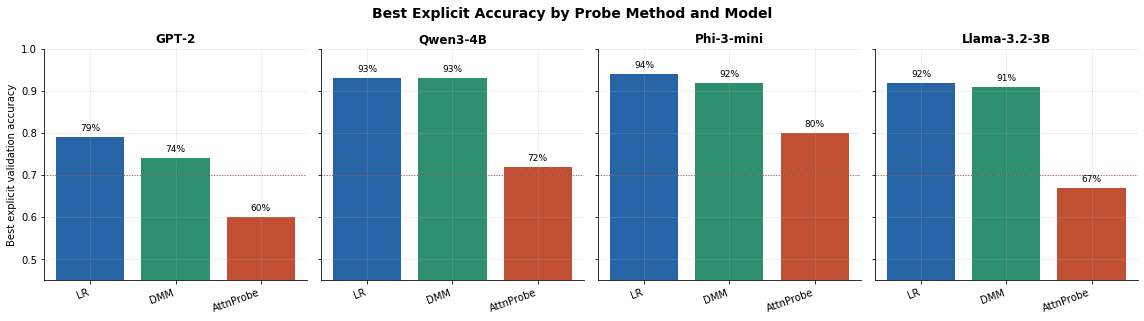

In [11]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(16, 4.2), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = summary_df[summary_df['model'] == model].sort_values('method')
    x = np.arange(len(sub))
    bars = ax.bar(x, sub['best_explicit_acc'], color=[METHOD_COLORS[m] for m in sub['method']])
    ax.axhline(0.70, color='#9c2f2f', lw=1, ls=':', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in sub['method']], rotation=20, ha='right')
    ax.set_title(MODEL_LABELS.get(model, model))
    ax.set_ylim(0.45, 1.0)
    for bar, val in zip(bars, sub['best_explicit_acc']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.0%}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Best explicit validation accuracy')
fig.suptitle('Best Explicit Accuracy by Probe Method and Model', y=1.05, fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'best_explicit_accuracy_bars.png', dpi=180, bbox_inches='tight')
plt.show()

## LR vs DMM: How Much Does a Learned Classifier Add?

DMM is a simple direction estimate. If LR and DMM are close, the temporal feature may be well-described by a mean-difference direction. If LR strongly beats DMM, the probe may need a more flexible linear boundary.


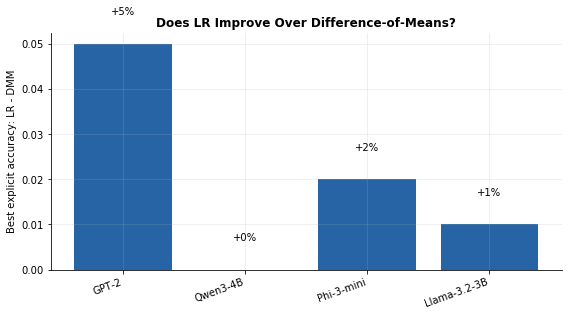

method,lr,dmm,lr_minus_dmm
model_label,,,
GPT-2,79.0%,74.0%,+5.0%
Qwen3-4B,93.0%,93.0%,+0.0%
Phi-3-mini,94.0%,92.0%,+2.0%
Llama-3.2-3B,92.0%,91.0%,+1.0%


In [12]:
lr_dmm = summary_df[summary_df['method'].isin(['lr', 'dmm'])].pivot(
    index='model_label', columns='method', values='best_explicit_acc'
)
lr_dmm['lr_minus_dmm'] = lr_dmm['lr'] - lr_dmm['dmm']
lr_dmm = lr_dmm.loc[[MODEL_LABELS[m] for m in MODEL_ORDER]]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#2764a5' if v >= 0 else '#2d8f6f' for v in lr_dmm['lr_minus_dmm']]
ax.bar(lr_dmm.index, lr_dmm['lr_minus_dmm'], color=colors)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Best explicit accuracy: LR - DMM')
ax.set_title('Does LR Improve Over Difference-of-Means?')
ax.set_xticklabels(lr_dmm.index, rotation=20, ha='right')
for i, val in enumerate(lr_dmm['lr_minus_dmm']):
    ax.text(i, val + (0.006 if val >= 0 else -0.012), f'{val:+.0%}', ha='center', va='bottom' if val >= 0 else 'top')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'lr_minus_dmm_delta.png', dpi=180, bbox_inches='tight')
plt.show()

lr_dmm.style.format({'lr': '{:.1%}', 'dmm': '{:.1%}', 'lr_minus_dmm': '{:+.1%}'})

## AttnProbe Diagnostics

AttnProbe uses 7 features per attention head per layer: entropy, max attention, attention to the last token, mean attention over the last 5 tokens, mean attention over the last 10 tokens, mean attention to the first half, and mean attention to the second half. The feature counts below should therefore equal `7 * n_heads` for each model.


In [13]:
attn_features = (
    layer_df[layer_df['method'] == 'attn']
    .groupby('model_label', observed=True)['n_features']
    .agg(['min', 'max'])
    .reset_index()
    .rename(columns={'model_label': 'Model', 'min': 'Min features/layer', 'max': 'Max features/layer'})
)
attn_features['Implied heads'] = attn_features['Max features/layer'] / 7
attn_features

,Model,Min features/layer,Max features/layer,Implied heads
0,GPT-2,84,84,12.0
1,Llama-3.2-3B,168,168,24.0
2,Phi-3-mini,224,224,32.0
3,Qwen3-4B,224,224,32.0


## Semantic Layer Coverage

Counting layers above 70% explicit accuracy gives a rough measure of how broadly a probe method detects transferable signal throughout the model.


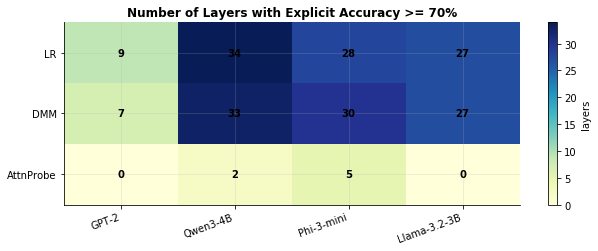

In [14]:
coverage_pivot = summary_df.pivot(index='method_label', columns='model_label', values='n_semantic_layers')
coverage_pivot = coverage_pivot.loc[[METHOD_LABELS[m] for m in METHOD_ORDER], [MODEL_LABELS[m] for m in MODEL_ORDER]]

fig, ax = plt.subplots(figsize=(9, 3.6))
im = ax.imshow(coverage_pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(coverage_pivot.columns)))
ax.set_xticklabels(coverage_pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(coverage_pivot.index)))
ax.set_yticklabels(coverage_pivot.index)
ax.set_title('Number of Layers with Explicit Accuracy >= 70%')
for i in range(coverage_pivot.shape[0]):
    for j in range(coverage_pivot.shape[1]):
        ax.text(j, i, int(coverage_pivot.values[i, j]), ha='center', va='center', fontweight='bold')
fig.colorbar(im, ax=ax, label='layers')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'semantic_layer_coverage_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

## Per-Case Detailed Tables

Use these if you want to inspect exact layer numbers and accuracies without reading JSON files by hand.


In [15]:
for method in METHOD_ORDER:
    display(Markdown(f'### {METHOD_LABELS[method]}'))
    method_table = layer_df[layer_df['method'] == method][[
        'model_label', 'layer', 'explicit_acc', 'implicit_acc', 'cv_mean', 'cv_std', 'gap_explicit_minus_implicit'
    ]].rename(columns={
        'model_label': 'Model',
        'layer': 'Layer',
        'explicit_acc': 'Explicit acc',
        'implicit_acc': 'Implicit acc',
        'cv_mean': 'CV mean',
        'cv_std': 'CV std',
        'gap_explicit_minus_implicit': 'Gap',
    })
    display(method_table.style.format({
        'Explicit acc': '{:.1%}',
        'Implicit acc': '{:.1%}',
        'CV mean': '{:.1%}',
        'CV std': '{:.1%}',
        'Gap': '{:+.1%}',
    }))

### LR

,Model,Layer,Explicit acc,Implicit acc,CV mean,CV std,Gap
0,GPT-2,0,68.0%,60.0%,61.3%,13.9%,+8.0%
1,GPT-2,1,67.0%,50.0%,55.0%,12.1%,+17.0%
2,GPT-2,2,67.0%,55.0%,61.3%,13.3%,+12.0%
3,GPT-2,3,70.0%,60.0%,63.7%,10.8%,+10.0%
4,GPT-2,4,79.0%,60.0%,66.2%,9.4%,+19.0%
5,GPT-2,5,77.0%,70.0%,65.0%,10.2%,+7.0%
6,GPT-2,6,79.0%,75.0%,65.0%,15.1%,+4.0%
7,GPT-2,7,78.0%,80.0%,63.7%,13.3%,-2.0%
8,GPT-2,8,78.0%,80.0%,63.7%,13.3%,-2.0%
9,GPT-2,9,75.0%,85.0%,66.2%,7.5%,-10.0%


### DMM

,Model,Layer,Explicit acc,Implicit acc,CV mean,CV std,Gap
108,GPT-2,0,72.0%,55.0%,58.8%,10.2%,+17.0%
109,GPT-2,1,64.0%,70.0%,56.2%,11.2%,-6.0%
110,GPT-2,2,68.0%,60.0%,63.7%,14.5%,+8.0%
111,GPT-2,3,67.0%,80.0%,65.0%,7.5%,-13.0%
112,GPT-2,4,68.0%,75.0%,62.5%,4.0%,-7.0%
113,GPT-2,5,69.0%,80.0%,60.0%,3.1%,-11.0%
114,GPT-2,6,72.0%,75.0%,67.5%,7.3%,-3.0%
115,GPT-2,7,72.0%,75.0%,66.2%,6.4%,-3.0%
116,GPT-2,8,74.0%,85.0%,68.8%,7.9%,-11.0%
117,GPT-2,9,74.0%,80.0%,70.0%,7.3%,-6.0%


### AttnProbe

,Model,Layer,Explicit acc,Implicit acc,CV mean,CV std,Gap
216,GPT-2,0,60.0%,45.0%,63.7%,7.3%,+15.0%
217,GPT-2,1,41.0%,50.0%,48.8%,10.8%,-9.0%
218,GPT-2,2,44.0%,40.0%,58.8%,9.4%,+4.0%
219,GPT-2,3,50.0%,35.0%,42.5%,8.3%,+15.0%
220,GPT-2,4,55.0%,65.0%,57.5%,15.0%,-10.0%
221,GPT-2,5,53.0%,65.0%,46.2%,16.1%,-12.0%
222,GPT-2,6,50.0%,60.0%,37.5%,6.8%,-10.0%
223,GPT-2,7,52.0%,65.0%,47.5%,3.1%,-13.0%
224,GPT-2,8,56.0%,55.0%,57.5%,7.3%,+1.0%
225,GPT-2,9,57.0%,70.0%,40.0%,12.9%,-13.0%


## Saved Figures

All generated figures are written to `results/figures/probe_validation_multimethod/` so they can be reused in reports without rerunning the notebook.


In [16]:
for path in sorted(FIGURE_DIR.glob('*.png')):
    print(path.relative_to(ROOT))

results/figures/probe_validation_multimethod/best_explicit_accuracy_bars.png
results/figures/probe_validation_multimethod/best_explicit_accuracy_heatmap.png
results/figures/probe_validation_multimethod/layer_accuracy_grid_all_cases.png
results/figures/probe_validation_multimethod/layer_generalization_gap.png
results/figures/probe_validation_multimethod/lr_minus_dmm_delta.png
results/figures/probe_validation_multimethod/mean_explicit_accuracy_heatmap.png
results/figures/probe_validation_multimethod/mean_generalization_gap_heatmap.png
results/figures/probe_validation_multimethod/normalized_depth_explicit_accuracy.png
results/figures/probe_validation_multimethod/semantic_layer_coverage_heatmap.png
